# CAD/USD Exchange Rate Prediction

Features:

1. Data Collection - Fetches 5 years of historical CAD/USD data from Yahoo Finance
2. Feature Engineering - Creates 25+ features including moving averages, RSI, Bollinger Bands, volatility, and lag features
3. Visualizations - 6 charts showing exchange rate trends, moving averages, volatility, RSI, return distributions, and Bollinger Bands
4. Multiple ML Models - Trains and compares Linear Regression, Random Forest, and Gradient Boosting
5. Performance Metrics - RMSE, MAE, and R² scores for all models
6. Predictions - Visualizes actual vs predicted values and makes next-day forecasts
7. Feature Importance - Shows which features matter most for predictions
8. Summary Statistics - Complete project report with key insights

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore')

In [2]:
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", package])

try:
    import yfinance as yf
except ImportError:
    print("Installing yfinance...")
    install_package("yfinance")
    import yfinance as yf

try:
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
except ImportError:
    print("Installing scikit-learn...")
    install_package("scikit-learn")
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=" * 80)
print("CAD/USD Exchange Rate Prediction")
print("=" * 80)

CAD/USD Exchange Rate Prediction


In [3]:
# ============================================================================
# SECTION 1: DATA COLLECTION
# ============================================================================
print("\n[1] Fetching CAD/USD Exchange Rate Data...")

# Fetch historical data for CAD/USD
ticker = "CADUSD=X"
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)  # 5 years of data

df = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Handle MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

if df.empty:
    print("Warning: Could not fetch data from Yahoo Finance. Using synthetic data for demonstration.")
    # Create synthetic data for demonstration
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    np.random.seed(42)
    # Simulate exchange rate around 0.72-0.78 USD per CAD
    base_rate = 0.75
    trend = np.linspace(0, 0.03, len(dates))
    noise = np.random.normal(0, 0.01, len(dates))
    seasonal = 0.02 * np.sin(np.linspace(0, 10*np.pi, len(dates)))
    rates = base_rate + trend + noise + seasonal
    
    df = pd.DataFrame({
        'Open': rates + np.random.normal(0, 0.001, len(dates)),
        'High': rates + np.abs(np.random.normal(0, 0.002, len(dates))),
        'Low': rates - np.abs(np.random.normal(0, 0.002, len(dates))),
        'Close': rates,
        'Volume': np.random.randint(0, 1000, len(dates))
    }, index=dates)

print(f"Data collected: {len(df)} trading days from {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nData shape: {df.shape}")
print(f"\nLast few rows:")
print(df.tail())


[1] Fetching CAD/USD Exchange Rate Data...
YF.download() has changed argument auto_adjust default to True
Data collected: 1298 trading days from 2021-02-12 to 2026-02-10

Data shape: (1298, 5)

Last few rows:
Price          Close      High       Low      Open  Volume
Date                                                      
2026-02-04  0.733170  0.733740  0.730919  0.733073       0
2026-02-05  0.731572  0.732429  0.729970  0.731561       0
2026-02-06  0.729278  0.733902  0.728672  0.729309       0
2026-02-09  0.732123  0.737191  0.731722  0.732263       0
2026-02-10  0.737343  0.739481  0.736637  0.737409       0


In [4]:
# ============================================================================
# SECTION 2: FEATURE ENGINEERING
# ============================================================================
print("\n[2] Engineering Features...")

# Create a copy for feature engineering
data = df.copy()

# Technical indicators
data['MA_7'] = data['Close'].rolling(window=7).mean()
data['MA_30'] = data['Close'].rolling(window=30).mean()
data['MA_90'] = data['Close'].rolling(window=90).mean()

# Volatility
data['Volatility'] = data['Close'].rolling(window=30).std()

# Price changes
data['Price_Change'] = data['Close'].pct_change()
data['Price_Change_7d'] = data['Close'].pct_change(periods=7)

# RSI (Relative Strength Index)
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands
data['BB_middle'] = data['Close'].rolling(window=20).mean()
data['BB_upper'] = data['BB_middle'] + 2 * data['Close'].rolling(window=20).std()
data['BB_lower'] = data['BB_middle'] - 2 * data['Close'].rolling(window=20).std()
data['BB_width'] = data['BB_upper'] - data['BB_lower']

# Lag features
for lag in [1, 2, 3, 5, 7]:
    data[f'Close_Lag_{lag}'] = data['Close'].shift(lag)

# Time-based features
data['Day_of_Week'] = data.index.dayofweek
data['Month'] = data.index.month
data['Quarter'] = data.index.quarter

# Target variable (next day's closing price)
data['Target'] = data['Close'].shift(-1)

# Drop NaN values
data = data.dropna()

print(f"Features created: {data.shape[1]} columns")
print(f"Samples after cleaning: {data.shape[0]} rows")


[2] Engineering Features...
Features created: 25 columns
Samples after cleaning: 1208 rows



[3] Visualizing Data...


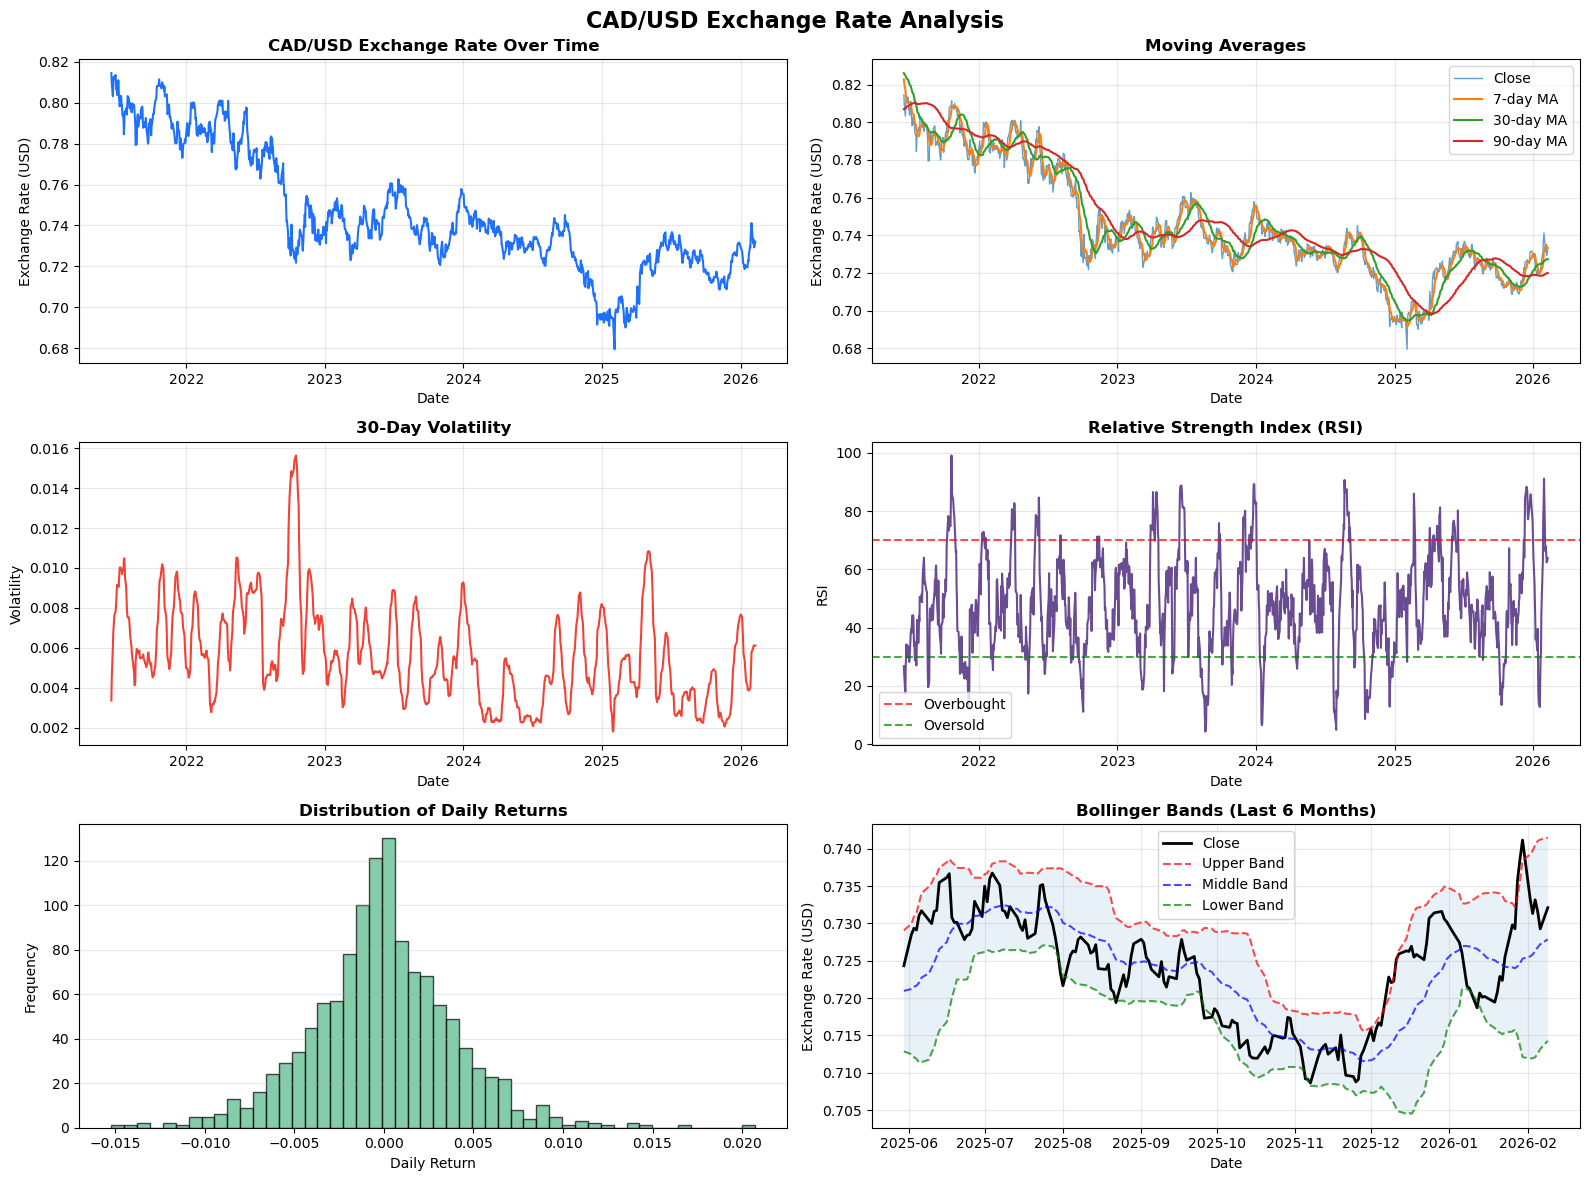

In [5]:
# ============================================================================
# SECTION 3: DATA VISUALIZATION
# ============================================================================
print("\n[3] Visualizing Data...")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('CAD/USD Exchange Rate Analysis', fontsize=16, fontweight='bold')

# Plot 1: Exchange rate over time
axes[0, 0].plot(data.index, data['Close'], linewidth=1.5, color='#1E70FF')
axes[0, 0].set_title('CAD/USD Exchange Rate Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Exchange Rate (USD)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Moving averages
axes[0, 1].plot(data.index, data['Close'], label='Close', linewidth=1, alpha=0.7)
axes[0, 1].plot(data.index, data['MA_7'], label='7-day MA', linewidth=1.5)
axes[0, 1].plot(data.index, data['MA_30'], label='30-day MA', linewidth=1.5)
axes[0, 1].plot(data.index, data['MA_90'], label='90-day MA', linewidth=1.5)
axes[0, 1].set_title('Moving Averages', fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Exchange Rate (USD)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Volatility
axes[1, 0].plot(data.index, data['Volatility'], color='#F24236', linewidth=1.5)
axes[1, 0].set_title('30-Day Volatility', fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Volatility')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: RSI
axes[1, 1].plot(data.index, data['RSI'], color='#6A4C93', linewidth=1.5)
axes[1, 1].axhline(y=70, color='r', linestyle='--', label='Overbought', alpha=0.7)
axes[1, 1].axhline(y=30, color='g', linestyle='--', label='Oversold', alpha=0.7)
axes[1, 1].set_title('Relative Strength Index (RSI)', fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('RSI')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Distribution of returns
axes[2, 0].hist(data['Price_Change'].dropna(), bins=50, color='#52B788', edgecolor='black', alpha=0.7)
axes[2, 0].set_title('Distribution of Daily Returns', fontweight='bold')
axes[2, 0].set_xlabel('Daily Return')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].grid(True, alpha=0.3, axis='y')

# Plot 6: Bollinger Bands
recent_data = data.tail(180)  # Last 6 months
axes[2, 1].plot(recent_data.index, recent_data['Close'], label='Close', linewidth=2, color='black')
axes[2, 1].plot(recent_data.index, recent_data['BB_upper'], label='Upper Band', linestyle='--', color='red', alpha=0.7)
axes[2, 1].plot(recent_data.index, recent_data['BB_middle'], label='Middle Band', linestyle='--', color='blue', alpha=0.7)
axes[2, 1].plot(recent_data.index, recent_data['BB_lower'], label='Lower Band', linestyle='--', color='green', alpha=0.7)
axes[2, 1].fill_between(recent_data.index, recent_data['BB_lower'], recent_data['BB_upper'], alpha=0.1)
axes[2, 1].set_title('Bollinger Bands (Last 6 Months)', fontweight='bold')
axes[2, 1].set_xlabel('Date')
axes[2, 1].set_ylabel('Exchange Rate (USD)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================================
# SECTION 4: PREPARE DATA FOR MODELING
# ============================================================================
print("\n[4] Preparing Data for Modeling...")

# Select features for modeling
feature_cols = [col for col in data.columns if col not in ['Target', 'Open', 'High', 'Low', 'Volume']]
X = data[feature_cols]
y = data['Target']

# Train-test split (80-20)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")


[4] Preparing Data for Modeling...
Training set: 966 samples
Testing set: 242 samples
Number of features: 20


In [7]:
# ============================================================================
# SECTION 5: MODEL TRAINING AND EVALUATION
# ============================================================================
print("\n[5] Training Multiple Models...")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'model': model,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2
    }
    
    print(f"  Train RMSE: {train_rmse:.6f}")
    print(f"  Test RMSE:  {test_rmse:.6f}")
    print(f"  Train MAE:  {train_mae:.6f}")
    print(f"  Test MAE:   {test_mae:.6f}")
    print(f"  Train R²:   {train_r2:.4f}")
    print(f"  Test R²:    {test_r2:.4f}")


[5] Training Multiple Models...

Training Linear Regression...
  Train RMSE: 0.003063
  Test RMSE:  0.002436
  Train MAE:  0.002326
  Test MAE:   0.001828
  Train R²:   0.9891
  Test R²:    0.9457

Training Random Forest...
  Train RMSE: 0.001407
  Test RMSE:  0.004676
  Train MAE:  0.001099
  Test MAE:   0.003518
  Train R²:   0.9977
  Test R²:    0.7997

Training Gradient Boosting...
  Train RMSE: 0.001227
  Test RMSE:  0.005573
  Train MAE:  0.000954
  Test MAE:   0.004144
  Train R²:   0.9982
  Test R²:    0.7155


In [8]:
# ============================================================================
# SECTION 6: MODEL COMPARISON AND RESULTS
# ============================================================================
print("\n[6] Comparing Models...")

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()]
})

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Select best model based on Test RMSE
best_model_name = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
best_model_results = results[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")


[6] Comparing Models...

Model Performance Comparison:
            Model  Test RMSE  Test MAE  Test R²
Linear Regression   0.002436  0.001828 0.945672
    Random Forest   0.004676  0.003518 0.799708
Gradient Boosting   0.005573  0.004144 0.715526

🏆 Best Model: Linear Regression



[7] Visualizing Predictions...


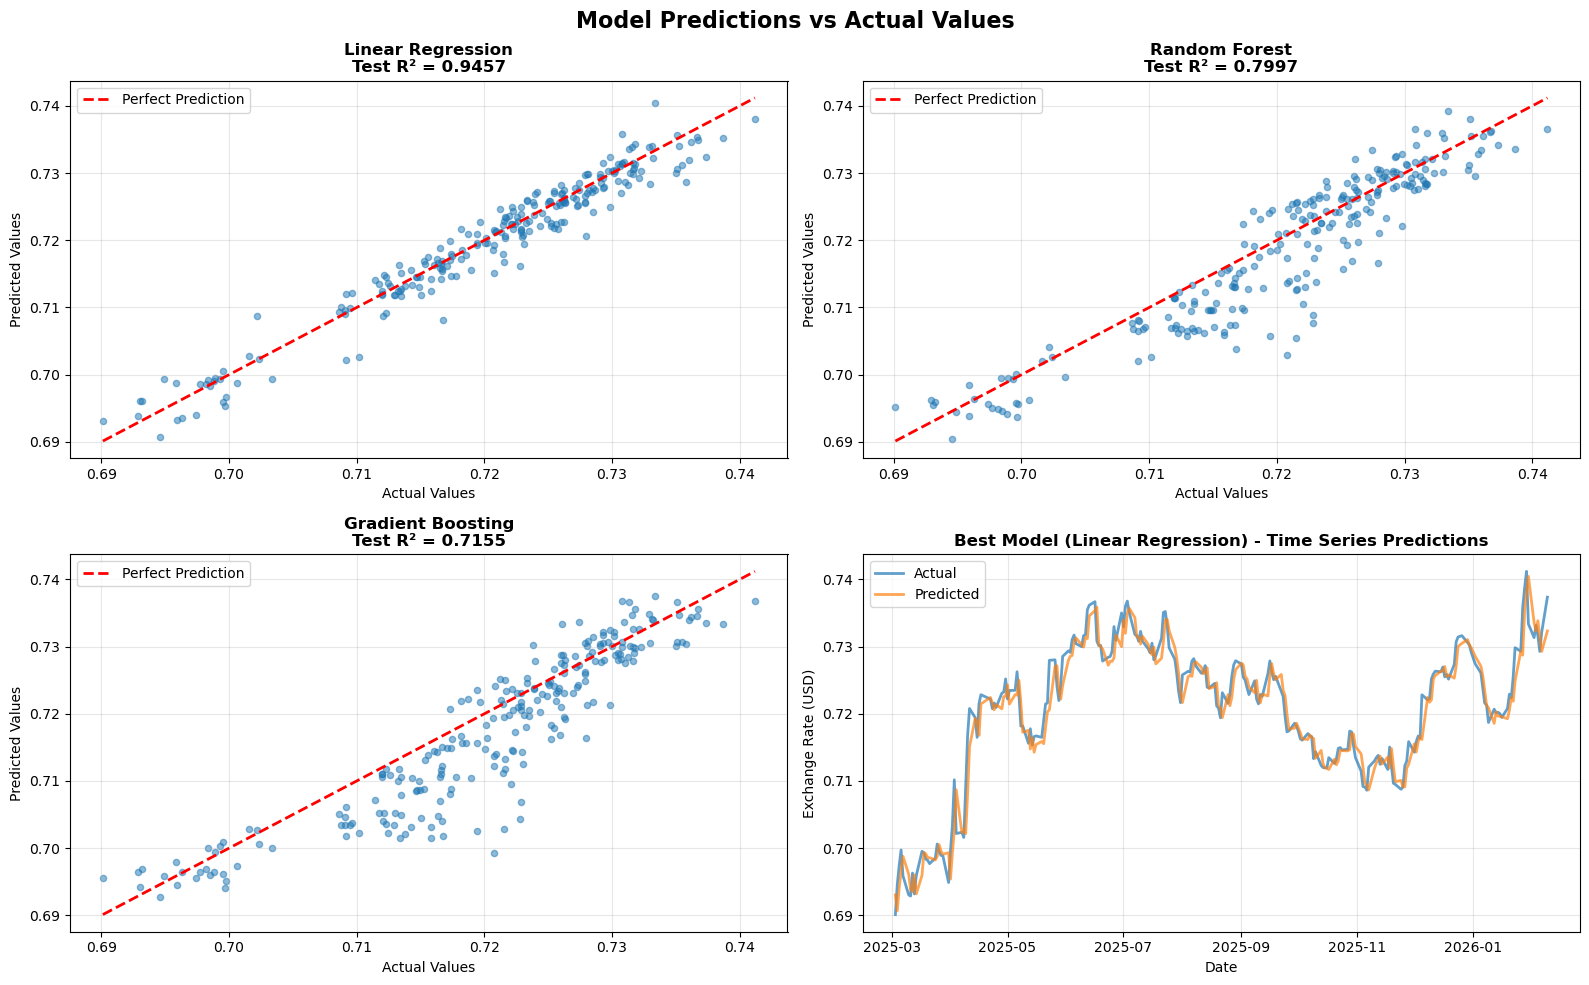

In [9]:
# ============================================================================
# SECTION 7: PREDICTIONS VISUALIZATION
# ============================================================================
print("\n[7] Visualizing Predictions...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Predictions vs Actual Values', fontsize=16, fontweight='bold')

for idx, (name, result) in enumerate(results.items()):
    row = idx // 2
    col = idx % 2
    
    if idx < 3:  # We have 3 models
        # Plot actual vs predicted for test set
        axes[row, col].scatter(y_test, result['y_pred_test'], alpha=0.5, s=20)
        axes[row, col].plot([y_test.min(), y_test.max()], 
                            [y_test.min(), y_test.max()], 
                            'r--', lw=2, label='Perfect Prediction')
        axes[row, col].set_xlabel('Actual Values')
        axes[row, col].set_ylabel('Predicted Values')
        axes[row, col].set_title(f'{name}\nTest R² = {result["test_r2"]:.4f}', fontweight='bold')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

# Time series plot for best model
axes[1, 1].plot(y_test.index, y_test.values, label='Actual', linewidth=2, alpha=0.7)
axes[1, 1].plot(y_test.index, best_model_results['y_pred_test'], 
                label='Predicted', linewidth=2, alpha=0.7)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Exchange Rate (USD)')
axes[1, 1].set_title(f'Best Model ({best_model_name}) - Time Series Predictions', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================================
# SECTION 8: FEATURE IMPORTANCE (for tree-based models)
# ============================================================================
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("\n[8] Feature Importance Analysis...")
    
    importances = best_model_results['model'].feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(12, 6))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()


In [11]:
# ============================================================================
# SECTION 9: FUTURE PREDICTIONS
# ============================================================================
print("\n[9] Making Future Predictions...")

# Use the last known data point to predict the next day
last_data_point = X_test_scaled[-1:, :]
next_day_prediction = best_model_results['model'].predict(last_data_point)[0]

print(f"\nLast known exchange rate: {y_test.iloc[-1]:.6f} USD")
print(f"Predicted next day rate:  {next_day_prediction:.6f} USD")
print(f"Expected change:          {(next_day_prediction - y_test.iloc[-1]):.6f} USD ({((next_day_prediction/y_test.iloc[-1] - 1)*100):.3f}%)")


[9] Making Future Predictions...

Last known exchange rate: 0.737343 USD
Predicted next day rate:  0.732317 USD
Expected change:          -0.005026 USD (-0.682%)


In [12]:
# ============================================================================
# SECTION 10: SUMMARY STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)
print(f"\n📊 Dataset Statistics:")
print(f"   - Total trading days analyzed: {len(df)}")
print(f"   - Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"   - Average exchange rate: {df['Close'].mean():.6f} USD")
print(f"   - Minimum rate: {df['Close'].min():.6f} USD")
print(f"   - Maximum rate: {df['Close'].max():.6f} USD")
print(f"   - Overall volatility (std): {df['Close'].std():.6f}")

print(f"\n🤖 Best Model Performance ({best_model_name}):")
print(f"   - Test RMSE: {best_model_results['test_rmse']:.6f}")
print(f"   - Test MAE:  {best_model_results['test_mae']:.6f}")
print(f"   - Test R²:   {best_model_results['test_r2']:.4f}")

print("\n✅ Project completed successfully!")
print("=" * 80)


PROJECT SUMMARY

📊 Dataset Statistics:
   - Total trading days analyzed: 1298
   - Date range: 2021-02-12 to 2026-02-10
   - Average exchange rate: 0.749658 USD
   - Minimum rate: 0.679486 USD
   - Maximum rate: 0.830703 USD
   - Overall volatility (std): 0.032622

🤖 Best Model Performance (Linear Regression):
   - Test RMSE: 0.002436
   - Test MAE:  0.001828
   - Test R²:   0.9457

✅ Project completed successfully!
